<a href="https://colab.research.google.com/github/ayushpaliwal1920/Deep_Learning/blob/main/14_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers


In [18]:
x,y = make_moons(100,noise=0.25,random_state=2)


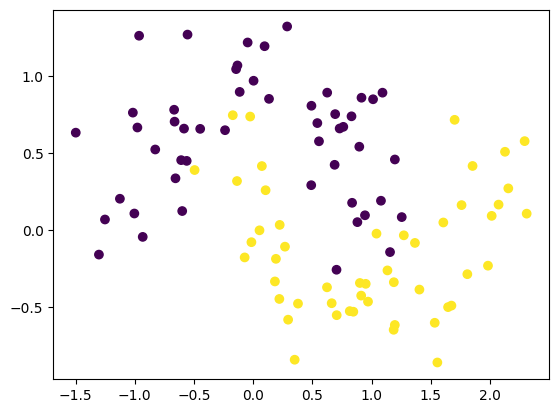

In [19]:
import matplotlib.pyplot as plt

plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

In [20]:
# model training

model1 = Sequential()

model1.add(Dense(128,input_dim = 2, activation = 'relu'))
model1.add(Dense(128,activation='relu'))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
adam = Adam(learning_rate=0.01)

model1.compile(loss='binary_crossentropy' , optimizer = adam, metrics = ["accuracy"])

history1 = model1.fit(x,y,epochs = 200,validation_split = 0.2 , verbose = 0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: >

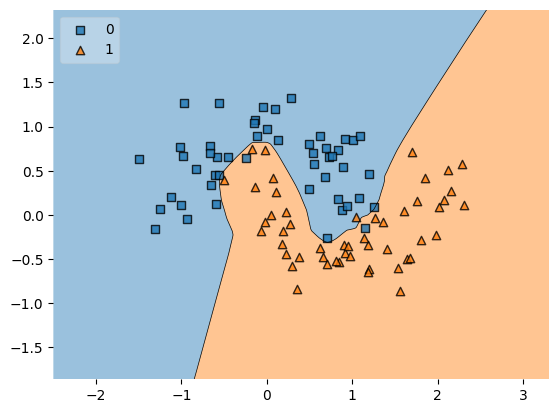

In [22]:
plot_decision_regions(x,y.astype('int'),clf = model1,legend=2)

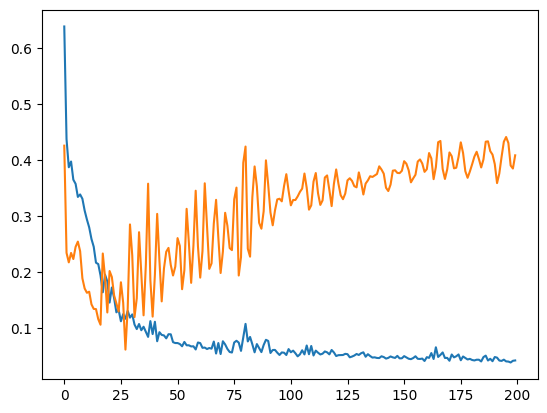

In [23]:
plt.plot(history1.history["loss"])
plt.plot(history1.history["val_loss"])


# Regularization :

In [24]:
model2 = Sequential()

# kernal_regularizer = tensorflow.keras.regularizers.l2(0.03) where 0.03 is value of lambda(strngth of regularization)
# for l1 regularization : tensorflow.keras.regularizers.l1(0.03), use l1 instead of l2

model2 = Sequential()

model2.add(Dense(128, input_dim=2, activation="relu",
                 kernel_regularizer=regularizers.l2(0.03)))

model2.add(Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.03)))

model2.add(Dense(1, activation='sigmoid'))

model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
adam = Adam(learning_rate=0.01)

model2.compile(loss='binary_crossentropy' , optimizer = adam, metrics = ["accuracy"])

history2 = model2.fit(x,y,epochs = 200,validation_split = 0.2 , verbose = 0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

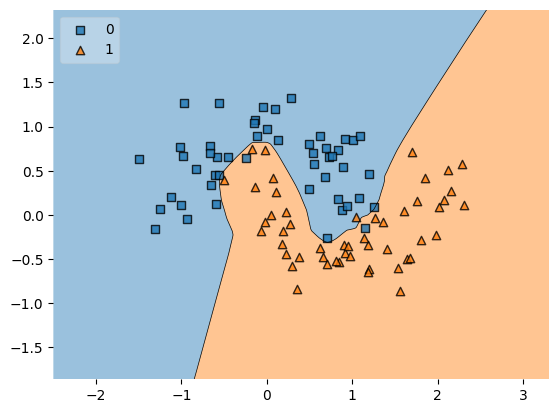

In [27]:
plot_decision_regions(x,y.astype('int'),clf = model1,legend=2)


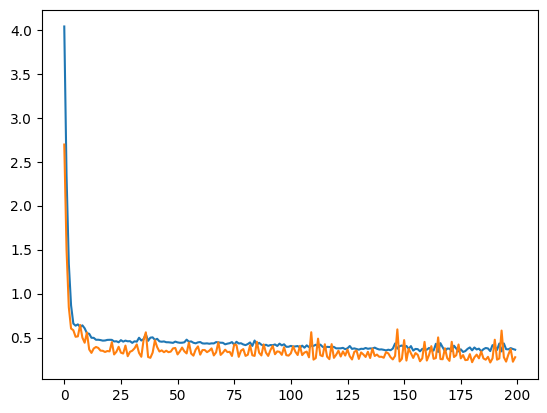

In [28]:
plt.plot(history2.history["loss"])
plt.plot(history2.history["val_loss"])


In [32]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)


<Axes: >

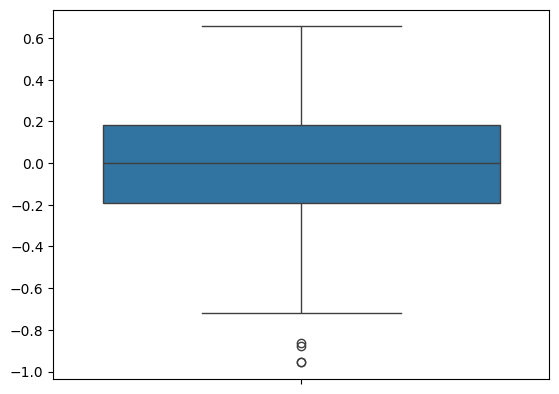

In [33]:
sns.boxplot(model1_weight_layer1)

<Axes: >

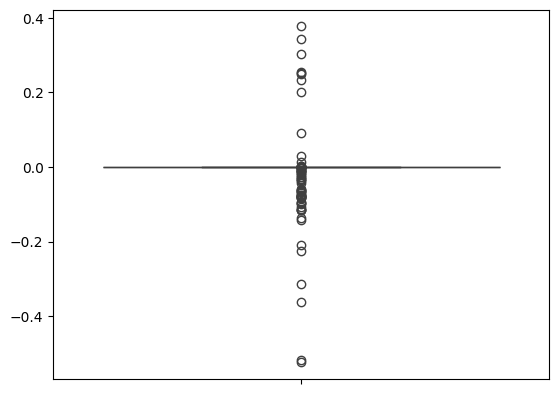

In [34]:
sns.boxplot(model2_weight_layer1)


In [35]:
model1_weight_layer1.max()

np.float32(0.65603036)

In [36]:
model2_weight_layer1.max()

np.float32(0.37699363)

/tmp/ipykernel_38747/3380537848.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
/tmp/ipykernel_38747/3380537848.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


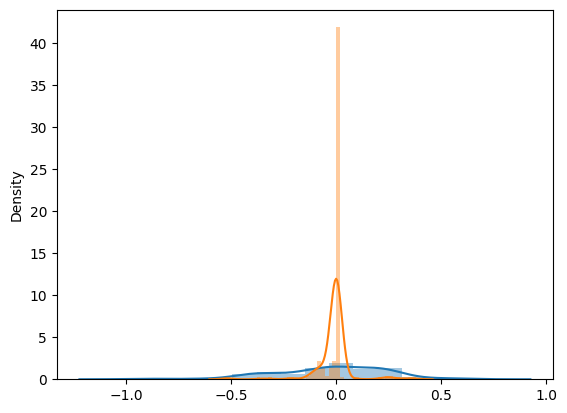

In [38]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)
plt.show()